In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [49]:
df = pd.read_csv('stock.csv')

In [51]:
df

,Date,Price
0,02-01-2022,105
1,03-01-2022,98
2,04-01-2022,110
3,05-01-2022,115
4,06-01-2022,112
5,07-01-2022,120
6,08-01-2022,125
7,09-01-2022,118
8,10-01-2022,130
9,11-01-2022,135


In [63]:
df = pd.DataFrame(data)

In [64]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Date'] = df['Date'].map(pd.Timestamp.toordinal)

In [65]:
X = df['Date'].values.reshape(-1, 1)  
y = df['Price'].values 

In [66]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

In [70]:
regressor = SVR(kernel='rbf')

In [72]:
regressor.fit(X_train, y_train.ravel())

SVR()

In [73]:
y_pred = regressor.predict(X_test)


In [74]:
y_pred_actual = scaler_y.inverse_transform(y_pred.reshape(-1, 1))

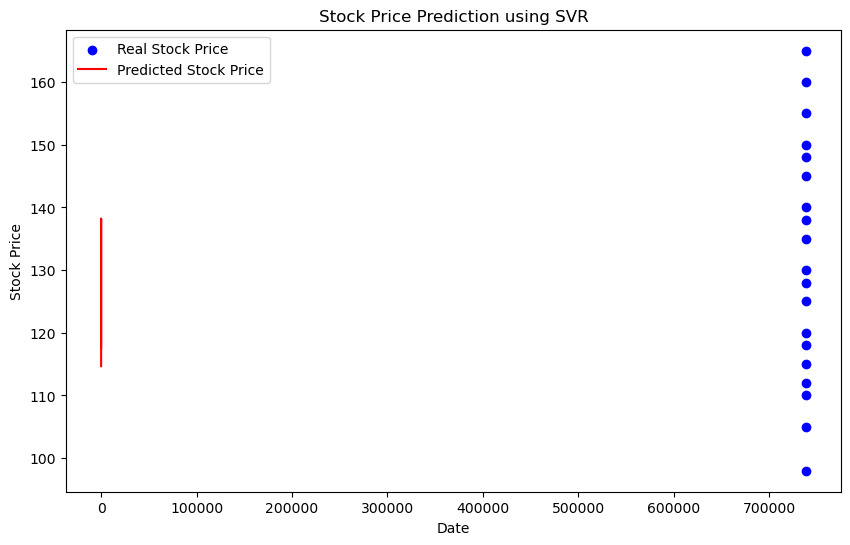

In [75]:
plt.figure(figsize=(10,6))
plt.scatter(X, y, color='blue', label='Real Stock Price')  # Plotting real prices
plt.plot(X_test, y_pred_actual, color='red', label='Predicted Stock Price')  # Plotting predicted prices
plt.title('Stock Price Prediction using SVR')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()